# Task 1a

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import math

# Load data
df = pd.read_csv("dataset_mood_smartphone.csv") 

In [2]:
# Show first few rows
df.head(5)

,Unnamed: 0,id,time,variable,value
0,1,AS14.01,2014-02-26 13:00:00.000,mood,6.0
1,2,AS14.01,2014-02-26 15:00:00.000,mood,6.0
2,3,AS14.01,2014-02-26 18:00:00.000,mood,6.0
3,4,AS14.01,2014-02-26 21:00:00.000,mood,7.0
4,5,AS14.01,2014-02-27 09:00:00.000,mood,6.0


In [3]:
# Make time datetime
df['time'] = pd.to_datetime(df['time'])

## Basic properties

In [4]:
print(f"Total records: {len(df)}")
print(f"Unique users: {df['id'].nunique()}")
print(f"Date range: {df['time'].min()} to {df['time'].max()}. Total days: {(df['time'].max() - df['time'].min()).days}")
print(f"Unique variables: {df['variable'].nunique()}")
print(f"Variable names: {np.array(df['variable'].unique())}")

# See how many records there are per user
records_per_user = df.groupby('id').size().sort_values()
print(f"Mean records per user: {records_per_user.mean():.0f}. Min: {records_per_user.min()}, Max: {records_per_user.max()}")

Total records: 376912
Unique users: 27
Date range: 2014-02-17 07:00:52.197000 to 2014-06-09 00:00:00. Total days: 111
Unique variables: 19
Variable names: ['mood' 'circumplex.arousal' 'circumplex.valence' 'activity' 'screen'
 'call' 'sms' 'appCat.builtin' 'appCat.communication'
 'appCat.entertainment' 'appCat.finance' 'appCat.game' 'appCat.office'
 'appCat.other' 'appCat.social' 'appCat.travel' 'appCat.unknown'
 'appCat.utilities' 'appCat.weather']
Mean records per user: 13960. Min: 2848, Max: 21999


## Data Distributions (Scatterplots)

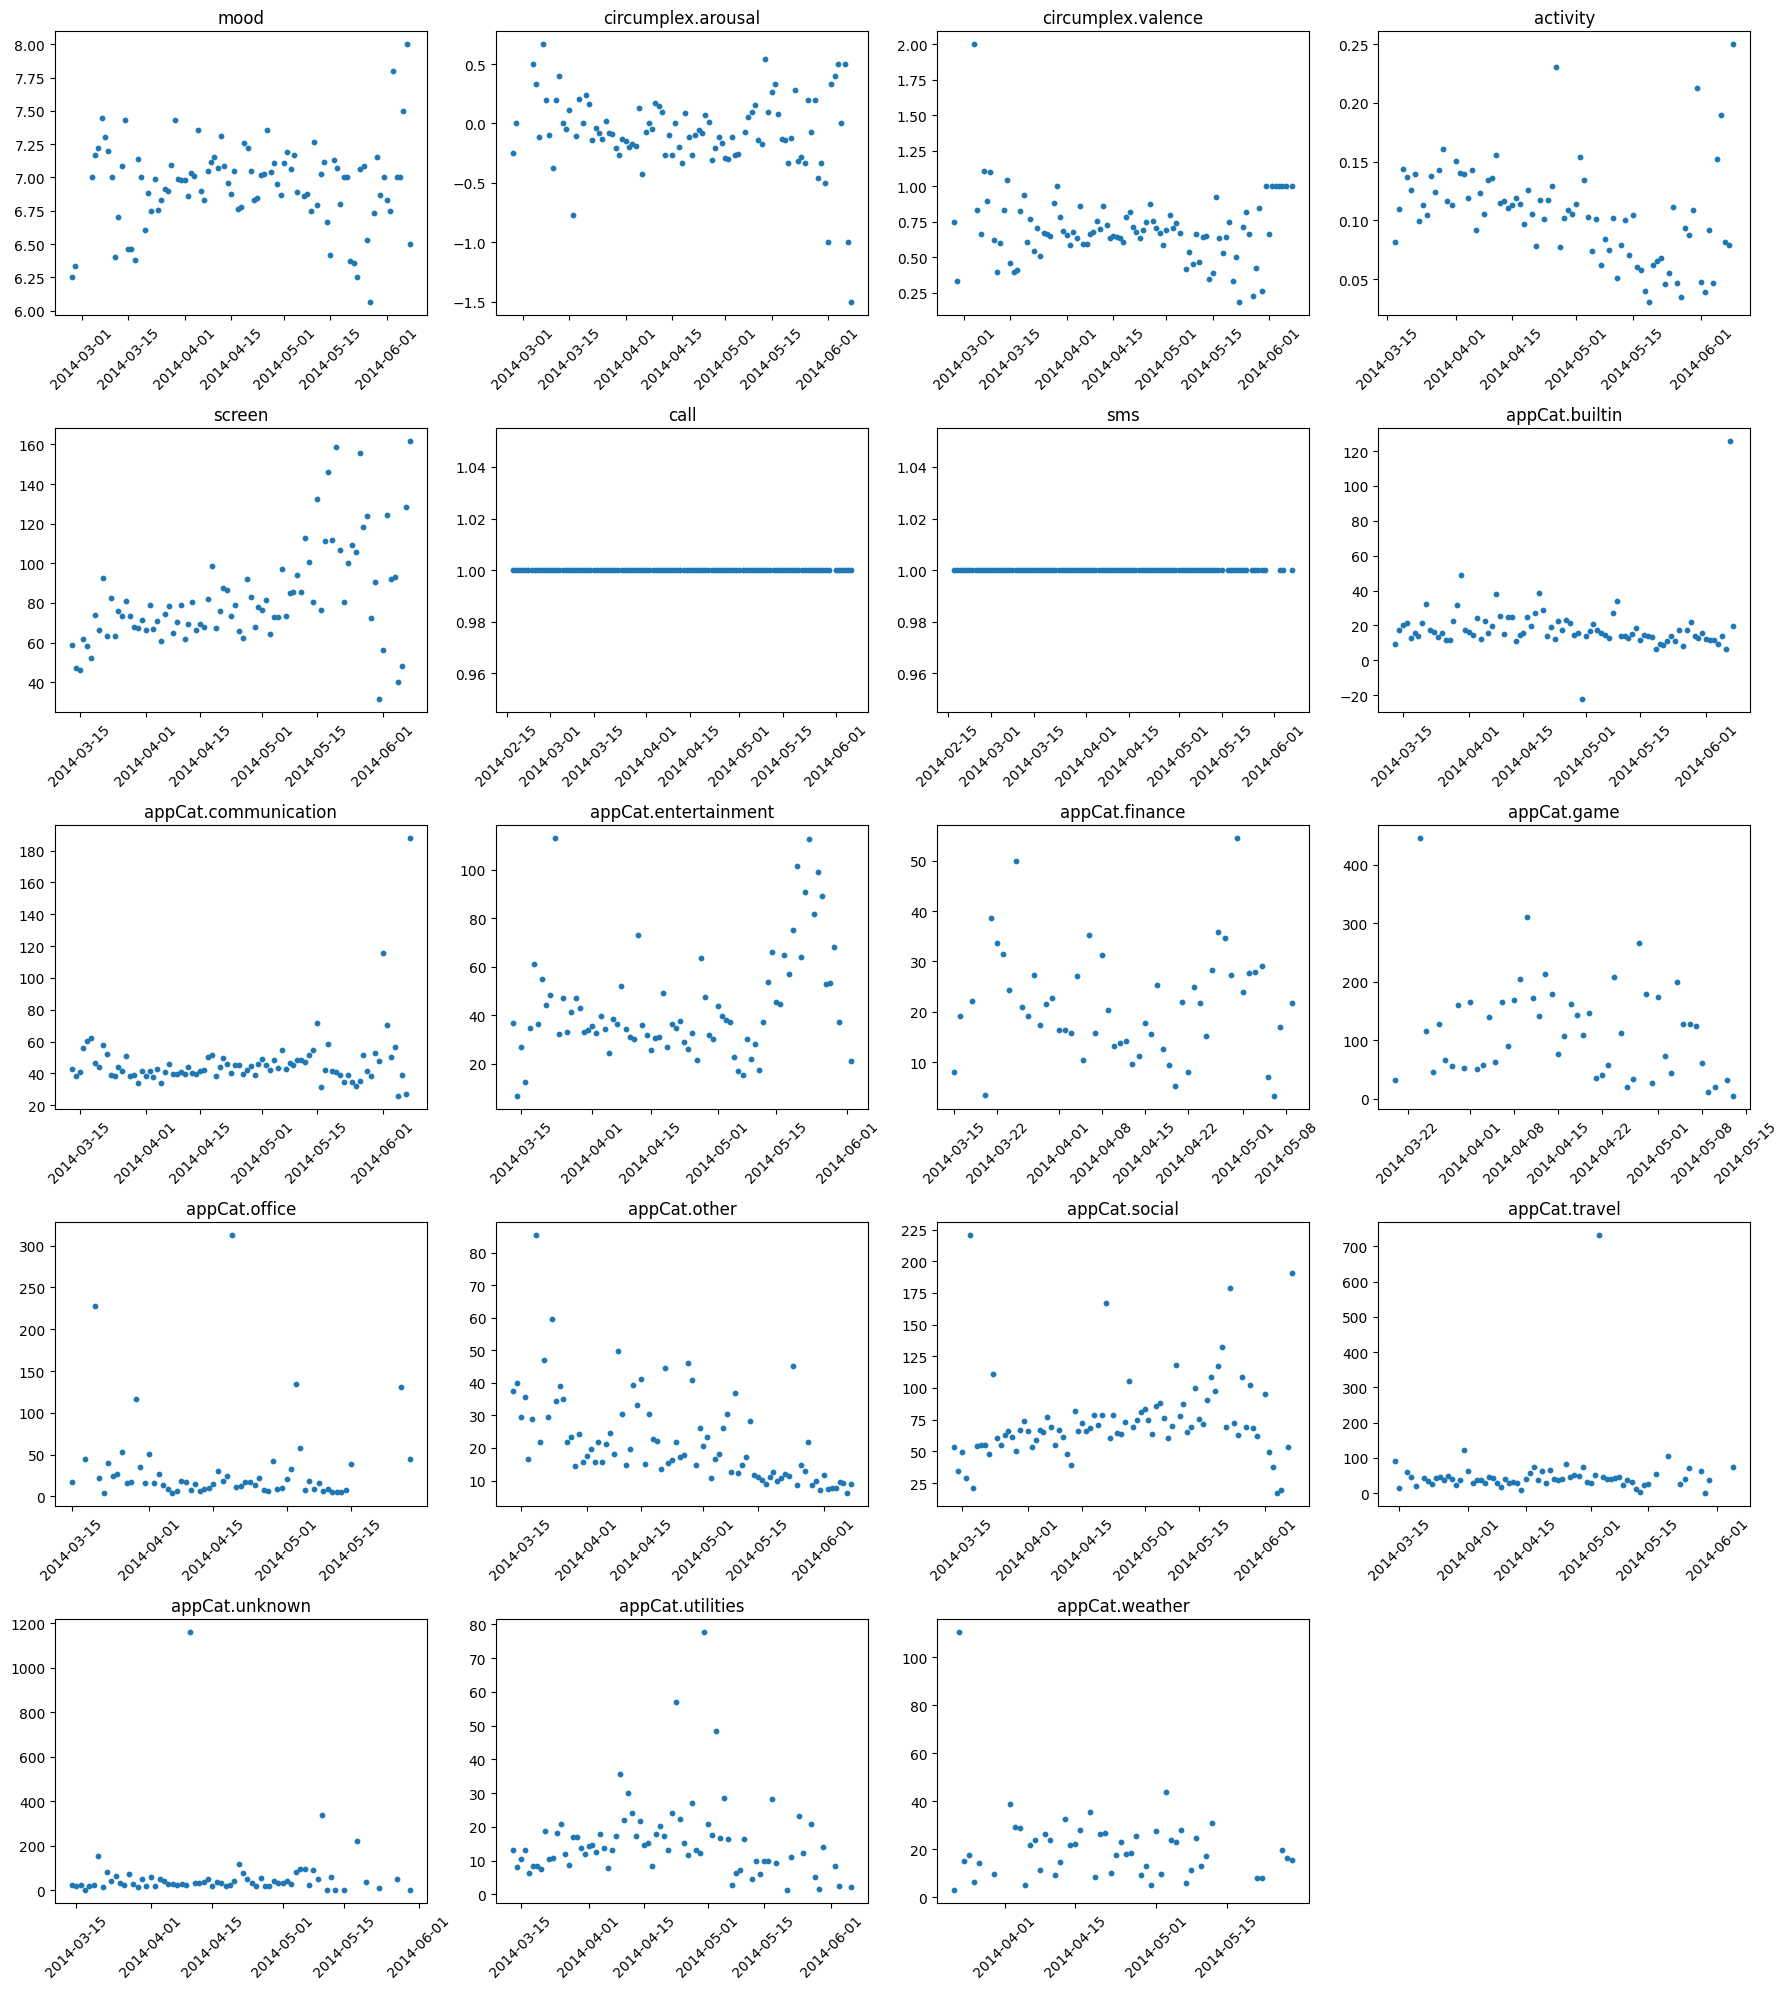

In [6]:
# Can be used to visualize aggregated data 

variables = np.array(df["variable"].unique())
n = len(variables)

# Plot 

cols = 4 
rows = math.ceil(n/cols)

fig, axes = plt.subplots(rows, cols, figsize = (18, 4*rows))
axes = axes.flatten()

for i, var in enumerate(variables):
    raw = df[df["variable"] == var].copy()

    daily = raw.groupby(pd.Grouper(key="time", freq="D"))["value"].mean()

    axes[i].scatter(daily.index, daily.values, s=10)
    axes[i].set_title(var)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Value ranges per variable sorted by count
df.groupby('variable')['value'].describe().round(3).sort_values(by='count', ascending=False)

,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
screen,96578.0,75.335,253.822,0.035,5.322,20.044,62.540,9867.007
appCat.builtin,91288.0,18.538,415.989,-82798.871,2.020,4.038,9.922,33960.246
appCat.communication,74276.0,43.344,128.913,0.006,5.218,16.226,45.476,9830.777
appCat.entertainment,27125.0,37.576,262.960,-0.011,1.334,3.391,14.922,32148.677
activity,22965.0,0.116,0.187,0.000,0.000,0.022,0.158,1.000
appCat.social,19145.0,72.402,261.552,0.094,9.030,28.466,75.372,30000.906
appCat.other,7650.0,25.811,112.781,0.014,7.019,10.028,16.829,3892.038
appCat.office,5642.0,22.579,449.601,0.003,2.004,3.106,8.044,32708.818
mood,5641.0,6.993,1.033,1.000,7.000,7.000,8.000,10.000


## Some plots to understand the data

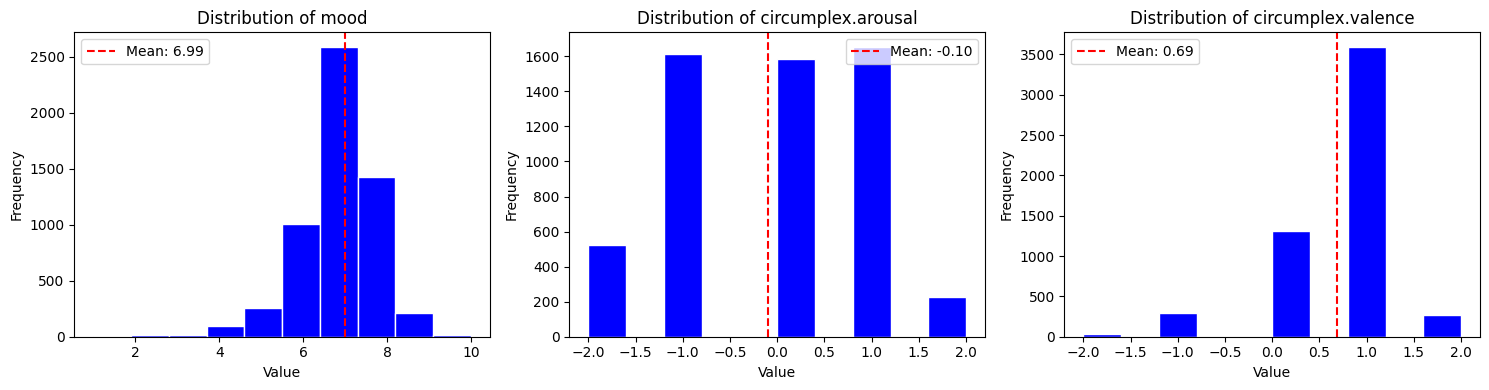

In [ ]:
# Plot histograms of self reported values
self_reported = ['mood', 'circumplex.arousal', 'circumplex.valence']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, var in zip(axes, self_reported):
    data = df[df['variable'] == var]['value']
    ax.hist(data.dropna(), bins=10, color='blue', edgecolor='white')
    ax.set_title(f'Distribution of {var}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.2f}')
    ax.legend()

plt.tight_layout()
plt.show()

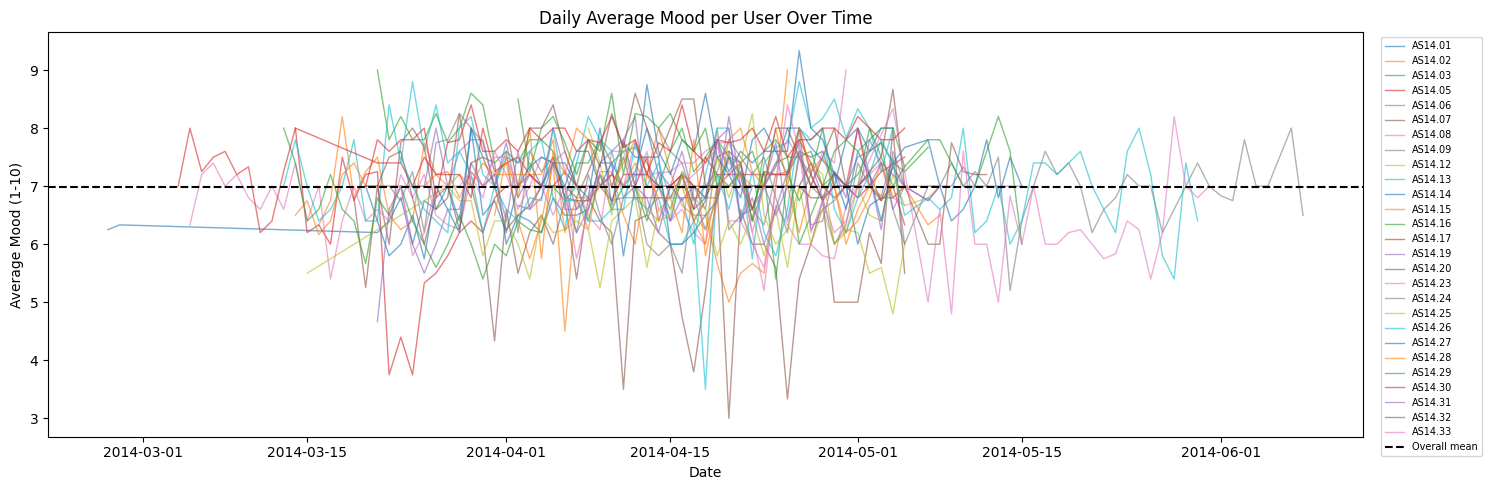

In [ ]:
# Mood over time per user
mood_df = df[df['variable'] == 'mood'].copy()
mood_df['date'] = mood_df['time'].dt.date

# Daily average mood per user
daily_mood = mood_df.groupby(['id', 'date'])['value'].mean().reset_index()

# Plot one line per user
fig, ax = plt.subplots(figsize=(15, 5))
for user_id, group in daily_mood.groupby('id'):
    ax.plot(group['date'], group['value'], alpha=0.6, linewidth=1, label=str(user_id))

ax.set_title('Daily Average Mood per User Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Average Mood (1-10)')
ax.axhline(daily_mood['value'].mean(), color='black', linestyle='--', linewidth=1.5, label='Overall mean')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
# Per-user date range
user_ranges = df.groupby('id')['time'].agg(['min','max'])
user_ranges['min'] = user_ranges['min'].dt.date
user_ranges['max'] = user_ranges['max'].dt.date
print(user_ranges)

                min         max
id                             
AS14.01  2014-02-17  2014-05-05
AS14.02  2014-02-17  2014-04-25
AS14.03  2014-02-17  2014-05-08
AS14.05  2014-02-18  2014-05-05
AS14.06  2014-02-17  2014-05-08
AS14.07  2014-03-17  2014-05-05
AS14.08  2014-02-17  2014-05-05
AS14.09  2014-02-17  2014-05-05
AS14.12  2014-02-19  2014-05-05
AS14.13  2014-02-17  2014-05-04
AS14.14  2014-02-17  2014-05-05
AS14.15  2014-02-17  2014-05-08
AS14.16  2014-02-17  2014-05-05
AS14.17  2014-02-17  2014-05-05
AS14.19  2014-02-17  2014-05-05
AS14.20  2014-02-17  2014-05-05
AS14.23  2014-02-17  2014-05-04
AS14.24  2014-04-09  2014-06-09
AS14.25  2014-02-17  2014-05-08
AS14.26  2014-02-17  2014-05-30
AS14.27  2014-02-17  2014-05-15
AS14.28  2014-02-17  2014-05-08
AS14.29  2014-02-17  2014-05-15
AS14.30  2014-02-17  2014-05-05
AS14.31  2014-02-17  2014-05-17
AS14.32  2014-02-17  2014-05-14
AS14.33  2014-02-17  2014-05-31


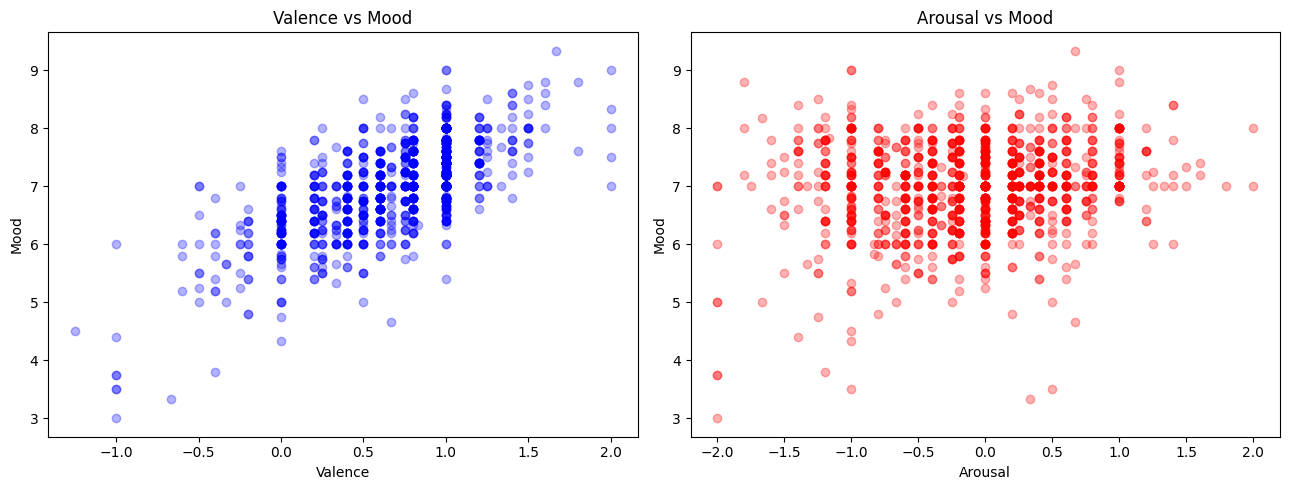

Correlation with mood:
variable
mood                  1.000000
circumplex.valence    0.685227
circumplex.arousal    0.152953
Name: mood, dtype: float64


In [ ]:
# See how mood depends on valence and arousal
circumplex_vars = ['mood', 'circumplex.arousal', 'circumplex.valence']
circ_df = df[df['variable'].isin(circumplex_vars)].copy()
circ_df['date'] = circ_df['time'].dt.date

circ_pivot = circ_df.pivot_table(index=['id', 'date'], 
                                   columns='variable', 
                                   values='value', 
                                   aggfunc='mean').reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(circ_pivot['circumplex.valence'], circ_pivot['mood'], 
                alpha=0.3, color='blue')
axes[0].set_xlabel('Valence')
axes[0].set_ylabel('Mood')
axes[0].set_title('Valence vs Mood')

axes[1].scatter(circ_pivot['circumplex.arousal'], circ_pivot['mood'], 
                alpha=0.3, color='red')
axes[1].set_xlabel('Arousal')
axes[1].set_ylabel('Mood')
axes[1].set_title('Arousal vs Mood')

plt.tight_layout()
plt.show()

# Print correlations
print("Correlation with mood:")
print(circ_pivot[['mood','circumplex.valence','circumplex.arousal']].corr()['mood'])

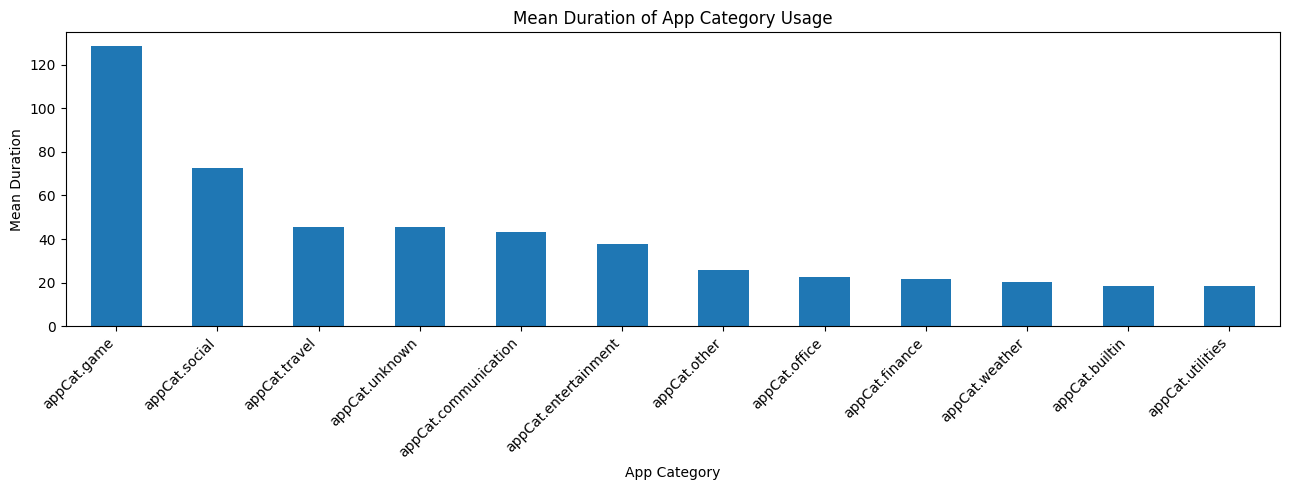

In [ ]:
# Mean Duration of App Category Usage
app_vars = [v for v in df['variable'].unique() if v.startswith('appCat')]

app_means = df[df['variable'].isin(app_vars)].groupby('variable')['value'].mean().sort_values(ascending=False)

plt.figure(figsize=(13, 5))
app_means.plot(kind='bar')
plt.title('Mean Duration of App Category Usage')
plt.ylabel('Mean Duration')
plt.xlabel('App Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Exploring missing values and outliers

In [ ]:
df['date'] = pd.to_datetime(df['time']).dt.date

# For each user, find all dates present
all_dates = df.groupby('id')['date'].apply(lambda x: sorted(x.unique())).reset_index()

# Find max gap per user
def max_gap(dates):
    if len(dates) < 2:
        return 0
    gaps = [(dates[i+1] - dates[i]).days for i in range(len(dates)-1)]
    return max(gaps)

all_dates['max_gap_days'] = all_dates['date'].apply(max_gap)
print(all_dates[['id','max_gap_days']].sort_values('max_gap_days', ascending=False))

         id  max_gap_days
21  AS14.28             8
6   AS14.08             7
16  AS14.23             6
22  AS14.29             6
9   AS14.13             4
15  AS14.20             4
14  AS14.19             4
7   AS14.09             4
8   AS14.12             4
23  AS14.30             3
12  AS14.16             3
0   AS14.01             3
10  AS14.14             3
20  AS14.27             3
4   AS14.06             3
3   AS14.05             3
18  AS14.25             3
24  AS14.31             2
25  AS14.32             2
13  AS14.17             2
19  AS14.26             2
11  AS14.15             2
2   AS14.03             2
26  AS14.33             2
17  AS14.24             1
1   AS14.02             1
5   AS14.07             1


In [ ]:
mood_df = df[df['variable'] == 'mood'].copy()
mood_df['date'] = pd.to_datetime(mood_df['time']).dt.date
mood_counts = mood_df.groupby('id')['date'].nunique()
print("Days with mood recorded per user:")
print(mood_counts.sort_values())

Days with mood recorded per user:
id
AS14.25    30
AS14.32    37
AS14.28    38
AS14.23    39
AS14.02    41
AS14.12    41
AS14.29    42
AS14.27    42
AS14.33    43
AS14.31    43
AS14.14    44
AS14.06    45
AS14.09    46
AS14.19    46
AS14.30    47
AS14.01    47
AS14.03    47
AS14.20    47
AS14.07    48
AS14.16    53
AS14.13    53
AS14.05    53
AS14.24    55
AS14.15    55
AS14.17    56
AS14.08    62
AS14.26    68
Name: date, dtype: int64
